
# 🎬 Top Movie — Greedy vs ε-Greedy Bandit Simulation

## Scenario
In the world of online streaming, **user satisfaction and engagement** are critical metrics for the success of a recommendation system.  
In this lab, we will consider a *movie recommendation scenario*. When a viewer watches a movie, they may enjoy it or not. **Bandit algorithms** can help identify the ***"best"*** movie by recommending movies to viewers and observing their reactions. A positive interaction is defined as a viewer enjoying the movie.

We will use the dataset, which contains ratings from different users for different movies. Ratings range from **1 (worst) to 5 (best)**. To simplify the ratings into a binary outcome, a rating of **5** will be considered a positive experience (**"liked"**), while all other ratings indicate a negative experience ("**disliked**"). Since movies have different numbers of ratings, longer simulations would normally be required to identify the best movie.

Each **movie** is treated as an *arm*, and every time a movie is recommended, we receive a *reward* (1 if the user liked it, 0 otherwise).

The challenge is balancing:
- **Exploration:** Trying new movies to learn more about user preferences.  
- **Exploitation:** Recommending movies already known to perform well.

---

## Objective
We will implement and compare two policies:
- **Greedy Policy:** Always selects the movie (arm) with the highest estimated reward.  
- **ε-Greedy Policy:** With probability ε, explores randomly; otherwise exploits the best movie.

We’ll simulate these methods on a real dataset of user–movie ratings.


In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline


In [12]:

# Load the dataset (ensure the CSV file is in the same directory)
rating_df = pd.read_csv('Top_Movie.csv').drop(columns='Unnamed: 0', errors='ignore')
print("Dataset shape:", rating_df.shape)
rating_df.head()


Dataset shape: (4863, 4)


,user_id,movie_id,rating,movie_title
0,307,0,4,Toy Story
1,250,99,4,Fargo
2,24,180,5,Return of the Jedi
3,19,287,1,Scream
4,31,293,3,Liar Liar


In [13]:

# Convert ratings into binary rewards
# Reward = 1 if rating >= 4 (user liked the movie), else 0
reward_threshold = 4
rating_df['reward'] = (rating_df['rating'] >= reward_threshold).astype(int)

print("Unique users:", rating_df['user_id'].nunique())
print("Unique movies:", rating_df['movie_id'].nunique())
rating_df.head()


Unique users: 927
Unique movies: 10


,user_id,movie_id,rating,movie_title,reward
0,307,0,4,Toy Story,1
1,250,99,4,Fargo,1
2,24,180,5,Return of the Jedi,1
3,19,287,1,Scream,0
4,31,293,3,Liar Liar,0


In [14]:

class BanditEnvironment:
    '''
    Simulates the environment for the Multi-Armed Bandit problem.
    Each movie is an 'arm'. Each recommendation is a 'pull' of that arm.
    '''
    def __init__(self, data, item_col='movie_id', user_col='user_id', reward_col='reward', random_seed=42):
        np.random.seed(random_seed)
        self.data = data
        self.item_col = item_col
        self.user_col = user_col
        self.reward_col = reward_col

        # Unique users and items (arms)
        self.items = data[item_col].unique()
        self.users = data[user_col].unique()
        self.n_items = len(self.items)
        self.n_users = len(self.users)

    def sample_user(self):
        '''Randomly pick a user from the dataset.'''
        return np.random.choice(self.users)

    def get_reward(self, item_id, user_id):
        '''
        Get the historical reward for a specific (user, movie) pair.
        If the pair does not exist, assume no feedback (reward = 0).
        '''
        reward = self.data.query(f"{self.item_col} == @item_id and {self.user_col} == @user_id")[self.reward_col]
        if len(reward) > 0:
            return reward.iloc[0]
        else:
            return 0


In [15]:
def run_greedy(env, n_visits=20000, n_iterations=20, verbose=False):
    all_runs = []
    total_counts = np.zeros(env.n_items)  # Track total selections per movie

    for it in tqdm(range(n_iterations), desc="Running Greedy Policy"):
        Q = np.zeros(env.n_items)
        N = np.zeros(env.n_items)
        total_reward = 0
        fraction_relevant = np.zeros(n_visits)

        for t in range(n_visits):
            arm = np.argmax(Q) if np.sum(N) > 0 else np.random.randint(env.n_items)
            user = env.sample_user()
            item_id = env.items[arm]
            reward = env.get_reward(item_id, user)

            N[arm] += 1
            total_counts[arm] += 1
            Q[arm] += (reward - Q[arm]) / N[arm]

            total_reward += reward
            fraction_relevant[t] = total_reward / (t + 1)

        all_runs.append(fraction_relevant)

    if verbose:
        top_idx = np.argmax(total_counts)
        print(f"Greedy Policy Top Movie: {env.items[top_idx]} (selected {int(total_counts[top_idx])} times)")
    return np.mean(all_runs, axis=0), total_counts, Q


In [16]:

def run_epsilon_greedy(env, epsilon=0.05, n_visits=20000, n_iterations=20, verbose=False):
    all_runs = []
    total_counts = np.zeros(env.n_items)
    final_Q = np.zeros(env.n_items)

    for it in tqdm(range(n_iterations), desc=f"Running ε-Greedy Policy (ε={epsilon})"):
        Q = np.zeros(env.n_items)
        N = np.zeros(env.n_items)
        total_reward = 0
        fraction_relevant = np.zeros(n_visits)

        for t in range(n_visits):
            arm = np.random.randint(env.n_items) if np.random.rand() < epsilon else np.argmax(Q)
            user = env.sample_user()
            item_id = env.items[arm]
            reward = env.get_reward(item_id, user)

            N[arm] += 1
            total_counts[arm] += 1
            Q[arm] += (reward - Q[arm]) / N[arm]

            total_reward += reward
            fraction_relevant[t] = total_reward / (t + 1)

        final_Q += Q
        all_runs.append(fraction_relevant)

    final_Q /= n_iterations  # average Q across runs
    if verbose:
        top_idx = np.argmax(final_Q)
        print(f"ε-Greedy Policy (ε={epsilon}) Top Movie: {env.items[top_idx]} (estimated reward {final_Q[top_idx]:.3f})")
    return np.mean(all_runs, axis=0), total_counts, final_Q


In [17]:

# Create environment
env = BanditEnvironment(rating_df)

# Define parameters
n_visits = 20000
n_iterations = 20

# Run Greedy and ε-Greedy policies
greedy_results, greedy_counts, greedy_Q = run_greedy(env, n_visits, n_iterations, verbose=True)

epsilons = [0.05, 0.1, 0.2]
epsilon_results = {}
epsilon_counts = {}
epsilon_Q = {}
for eps in epsilons:
    epsilon_results[eps], epsilon_counts[eps], epsilon_Q[eps] = run_epsilon_greedy(env, epsilon=eps, n_visits=n_visits, n_iterations=n_iterations, verbose=True)


Running Greedy Policy: 100%|██████████| 20/20 [12:17<00:00, 36.85s/it]


Greedy Policy Top Movie: 0 (selected 299986 times)


Running ε-Greedy Policy (ε=0.05): 100%|██████████| 20/20 [12:13<00:00, 36.68s/it]


ε-Greedy Policy (ε=0.05) Top Movie: 49 (estimated reward 0.541)


Running ε-Greedy Policy (ε=0.1): 100%|██████████| 20/20 [12:15<00:00, 36.78s/it]


ε-Greedy Policy (ε=0.1) Top Movie: 49 (estimated reward 0.540)


Running ε-Greedy Policy (ε=0.2): 100%|██████████| 20/20 [12:01<00:00, 36.08s/it]

ε-Greedy Policy (ε=0.2) Top Movie: 49 (estimated reward 0.540)


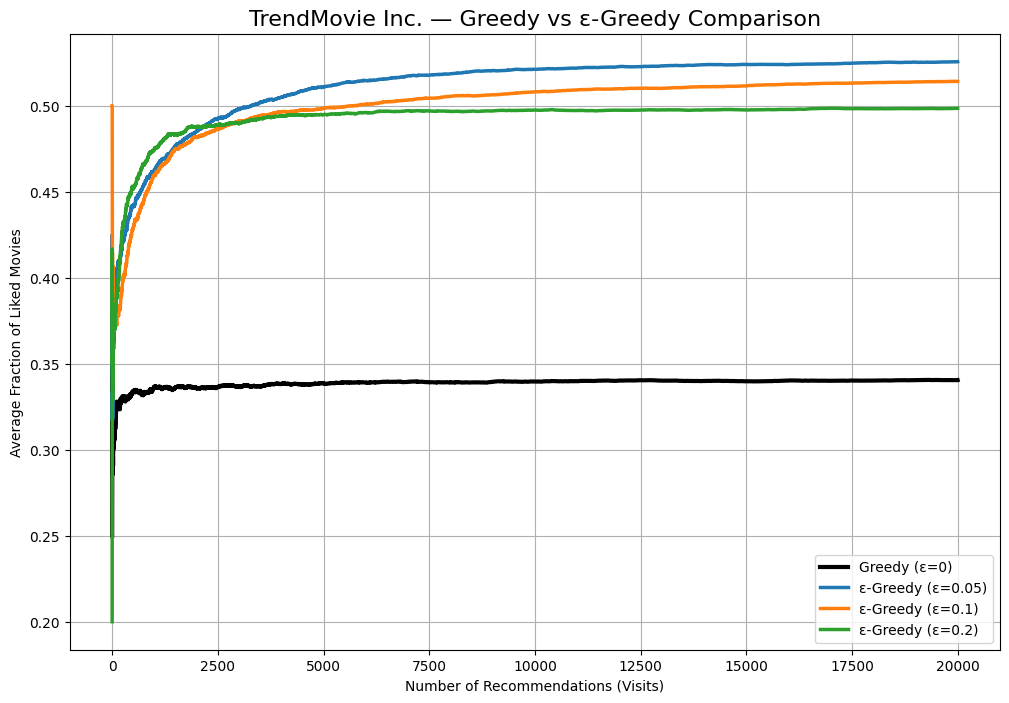

In [18]:

plt.figure(figsize=(12,8))

plt.plot(greedy_results, label='Greedy (ε=0)', linewidth=3, color='black')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for eps, color in zip(epsilons, colors):
    plt.plot(epsilon_results[eps], label=f'ε-Greedy (ε={eps})', linewidth=2.5, color=color)

plt.title('TrendMovie Inc. — Greedy vs ε-Greedy Comparison', fontsize=16)
plt.xlabel('Number of Recommendations (Visits)')
plt.ylabel('Average Fraction of Liked Movies')
plt.legend()
plt.grid(True)
plt.show()


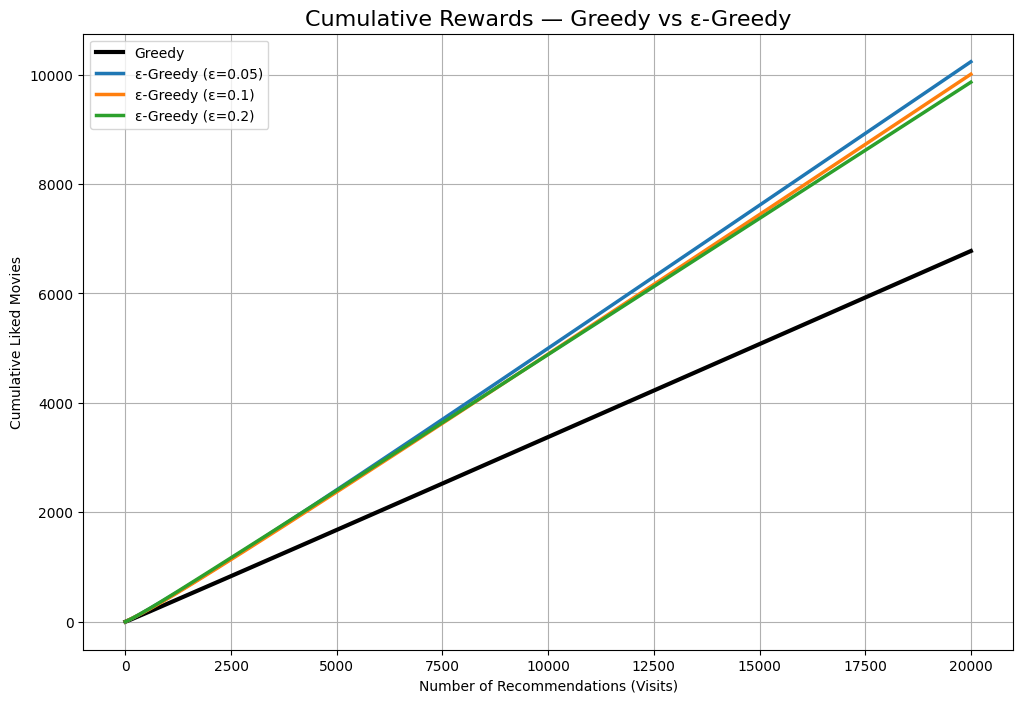

In [19]:
plt.figure(figsize=(12,8))
plt.plot(np.cumsum(greedy_results), label='Greedy', linewidth=3, color='black')
for eps, color in zip(epsilons, colors):
    plt.plot(np.cumsum(epsilon_results[eps]), label=f'ε-Greedy (ε={eps})', linewidth=2.5, color=color)
plt.title('Cumulative Rewards — Greedy vs ε-Greedy', fontsize=16)
plt.xlabel('Number of Recommendations (Visits)')
plt.ylabel('Cumulative Liked Movies')
plt.legend()
plt.grid(True)
plt.show()



## 🧠 Conclusion

- **Greedy Policy (ε=0):** Exploits the current best option but can get stuck on suboptimal movies because it never explores new ones.  
- **ε-Greedy Policy:** Introduces randomness, helping discover better movies by occasionally exploring.  

✅ **Observation:**  
Exploration (ε > 0) allows the system to adapt and avoid premature convergence to suboptimal recommendations.
